In [2]:
import pandas as pd

df = pd.read_csv('titanic_disaster.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


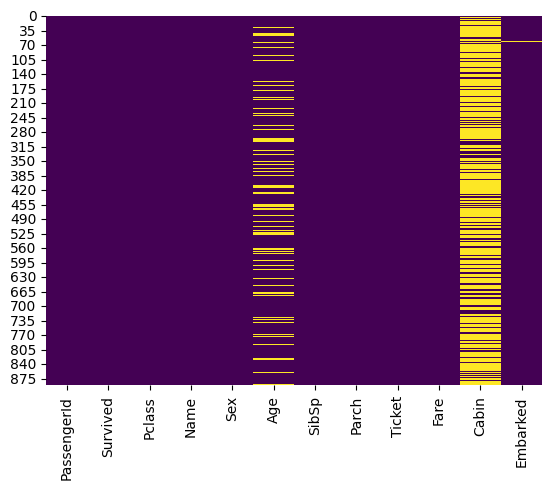

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [4]:
df[['firstName', 'secondName']] = df['Name'].str.split(',', n=1, expand=True)
df.drop(columns=['Name'], inplace=True)

In [5]:
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})

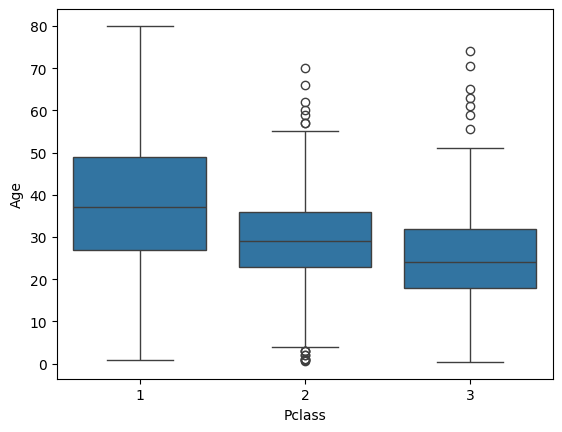

In [6]:
sns.boxplot(x='Pclass', y='Age', data=df)
plt.show()

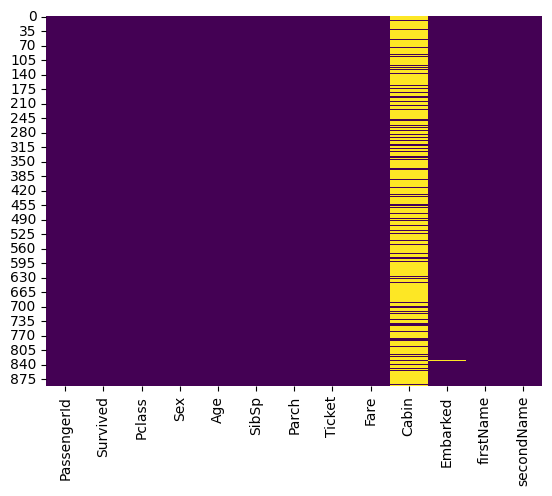

In [7]:
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [8]:
df['Agegroup'] = pd.cut(df['Age'], bins=[-1, 12, 18, 60, 150], labels=['Kid', 'Teen', 'Adult', 'Older'])

In [9]:
df['namePrefix'] = df['secondName'].str.split('.').str[0].str.strip()

In [10]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']

In [11]:
df['Alone'] = (df['familySize'] == 1).astype(int)

In [12]:
df['typeCabin'] = df['Cabin'].astype(str).str[0].replace('n', 'Unknown')

In [13]:

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName,Agegroup,namePrefix,familySize,Alone,typeCabin
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris,Adult,Mr,2,0,Unknown
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Adult,Mrs,2,0,C
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina,Adult,Miss,1,1,Unknown
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel),Adult,Mrs,2,0,C
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry,Adult,Mr,1,1,Unknown


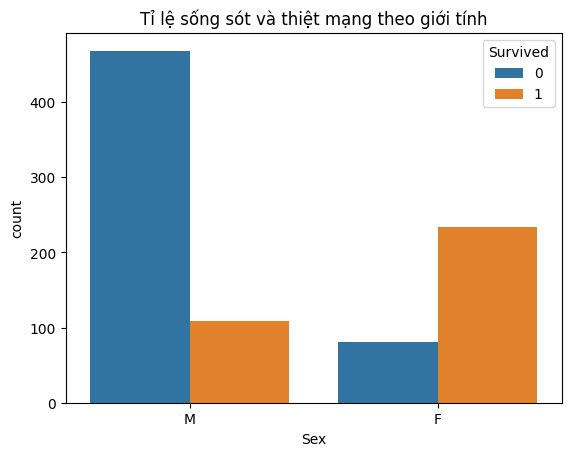

In [14]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Tỉ lệ sống sót và thiệt mạng theo giới tính')
plt.show()

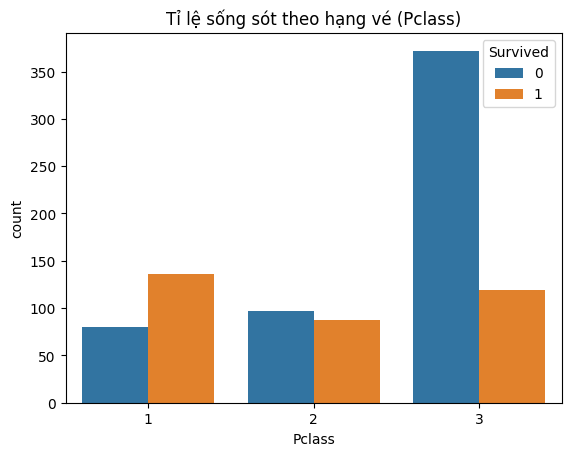

In [15]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Tỉ lệ sống sót theo hạng vé (Pclass)')
plt.show()

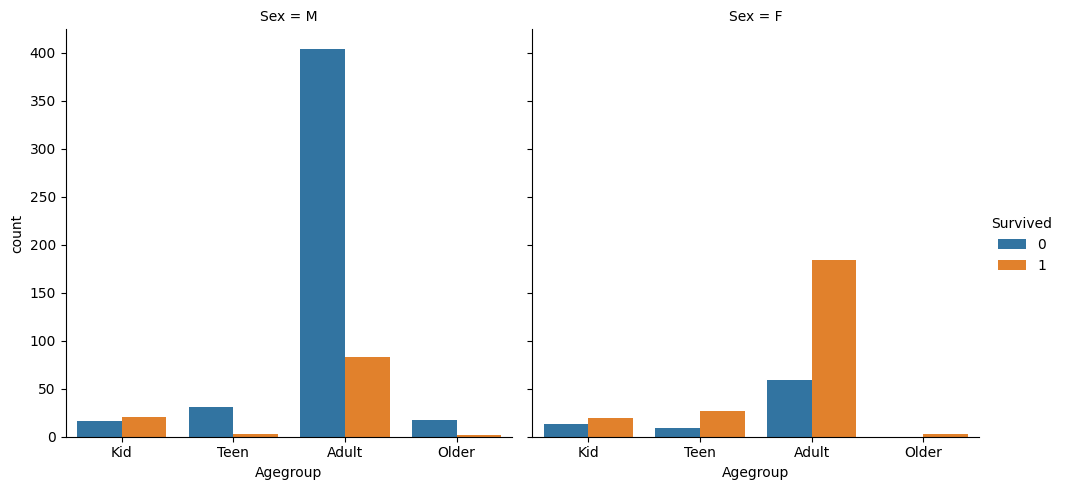

In [16]:
sns.catplot(x='Agegroup', hue='Survived', col='Sex', data=df, kind='count')
plt.show()

/tmp/ipykernel_12470/3464710055.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='familySize', y='Survived', data=df, ci=None)


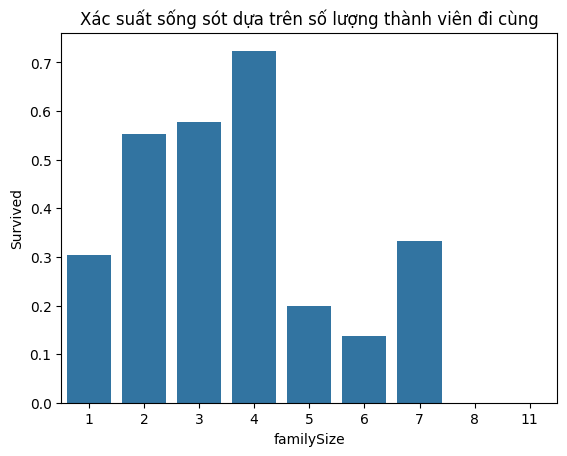

In [17]:
sns.barplot(x='familySize', y='Survived', data=df, ci=None)
plt.title('Xác suất sống sót dựa trên số lượng thành viên đi cùng')
plt.show()

/tmp/ipykernel_12470/1909054209.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='Fare', hue='Survived', shade=True)


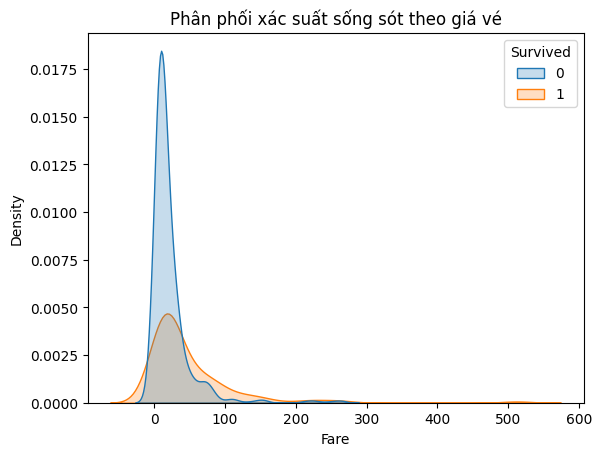

In [18]:
sns.kdeplot(data=df, x='Fare', hue='Survived', shade=True)
plt.title('Phân phối xác suất sống sót theo giá vé')
plt.show()

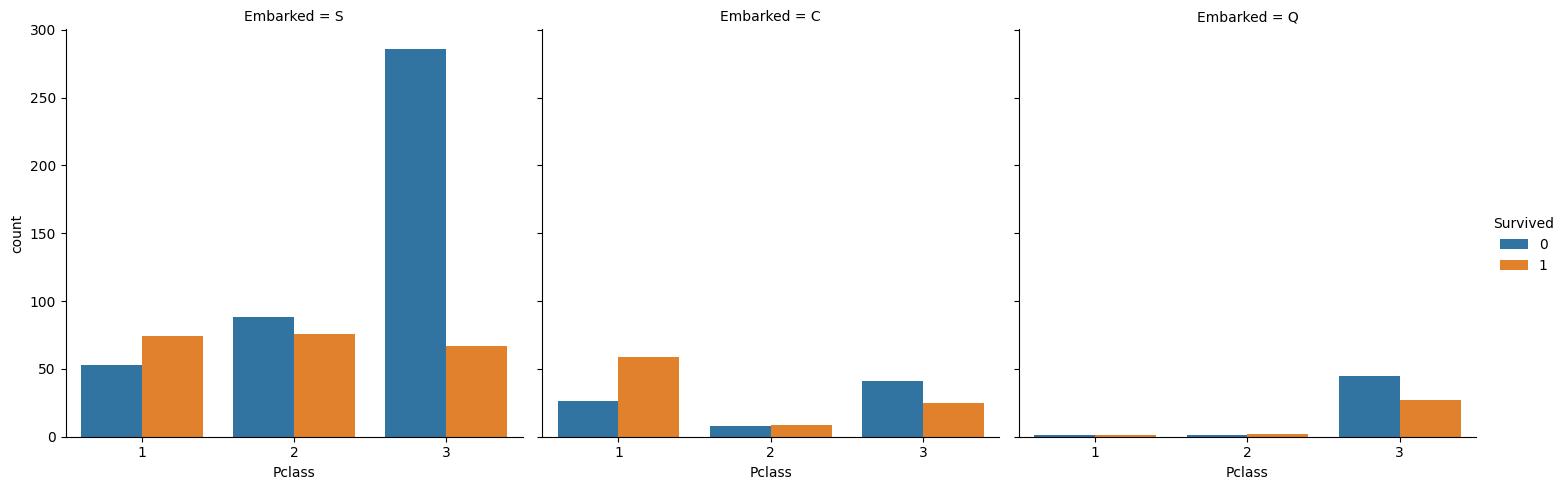

In [19]:
sns.catplot(x='Pclass', hue='Survived', col='Embarked', data=df, kind='count')
plt.show()